# Finetune DINOv2 — RETFound (DINOv2 backbone) for Diabetic Retinopathy

A **backbone-swap replica** of `RETFound_DR_finetune.ipynb`. Identical data, split, recipe,
and selection metric — the ONLY change is the pretrained backbone:

| | Baseline notebook | **This notebook** |
|---|---|---|
| backbone | RETFound **MAE** ViT-L/16 (`RETFound_mae_natureCFP`) | RETFound **DINOv2** ViT-L/14 (`RETFound_dinov2_meh`) |
| checkpoint key | `model` | `teacher` |
| input / patches | 224px / 16×16 | 224px / 16×16 (patch14; pos-embed interp 37×37→16×16) |
| loss | weighted CE | weighted CE *(same)* |
| selection metric | val QWK | **val macro-AUROC** (QWK intentionally not measured here) |

Everything downstream (manifest, patient-level split, ImageFolder cache, 4-class ordinal
R0–R3, macro-AUROC eval, referable-DR view) is shared with the baseline, so results are
directly comparable — this isolates the effect of the backbone.

### Verified laterality mapping (unchanged): OD=RIGHT=RE, OS=LEFT=LE; CSV Left/Right → LE/RE.
### Usable data (unchanged): 8407 images / 3834 eyes / 2194 patients; patient-level 70/15/15.

## ⚠️ Gated model access — do this once
`RETFound_dinov2_meh` is **also gated** on Hugging Face. Accept the form at
<https://huggingface.co/YukunZhou/RETFound_dinov2_meh> and
`huggingface-cli login --token <YOUR_HF_TOKEN>` (set `HF_ENDPOINT` mirror if HF is blocked).
The DINOv2 base weights (`timm/vit_large_patch14_dinov2.lvd142m`) download automatically and
are not gated.

In [1]:
# --- ensure Phases 0-3 + cache + RETFound repo exist (skips if built) ---
import os, subprocess, sys
assert os.path.isdir("pipeline"), "Run from project root (Retfound.V2/)."
if not os.path.isdir("outputs/dr_imagefolder"):
    for s in ["build_manifest.py", "make_split.py", "materialize_imagefolder.py"]:
        print("running", s); subprocess.run([sys.executable, f"pipeline/{s}"], check=True)
if not os.path.isdir("outputs/dr_imagefolder_cache"):
    subprocess.run([sys.executable, "pipeline/build_resized_cache.py", "--size", "512"], check=True)
if not os.path.isdir("RETFound_repo"):
    subprocess.run(["git","clone","--depth","1","https://github.com/rmaphoh/RETFound.git","RETFound_repo"], check=True)
    subprocess.run([sys.executable,"-m","pip","install","-q","-r","RETFound_repo/requirements.txt"], check=True)
print("ready")

ready


In [2]:
# ============================ CONFIG (DINOv2 backbone) ============================
CONFIG = dict(
    data_path   = "outputs/dr_imagefolder_cache",
    nb_classes  = 4,
    input_size  = 224,                          # DINOv2 builder fixes img_size=224 (patch14)
    # --- the backbone swap ---
    model       = "RETFound_dinov2",            # vs "RETFound_mae"
    model_arch  = "dinov2_vitl14",
    finetune_id = "RETFound_dinov2_meh",        # GATED HF weights (checkpoint key: "teacher")
    drop_path   = 0.2,
    adaptation  = "finetune",

    # recipe identical to the baseline
    batch_size    = 16, accum_iter = 4,         # eff batch 64 (DINOv2@224 ~5GB @bs8, fits)
    epochs        = 50, warmup_epochs = 10,
    blr = 5e-3, layer_decay = 0.65, weight_decay = 0.05, min_lr = 1e-6, clip_grad = None,
    device = "cuda", seed = 42, num_workers = 10,
    output_dir = "outputs/finetune_dinov2",
    task = "dr_dinov2_224",
)
SELECTION_METRIC = "macro_auroc"                  # QWK intentionally NOT used in this experiment
import os; os.makedirs(CONFIG["output_dir"], exist_ok=True)
CONFIG

{'data_path': 'outputs/dr_imagefolder_cache',
 'nb_classes': 4,
 'input_size': 224,
 'model': 'RETFound_dinov2',
 'model_arch': 'dinov2_vitl14',
 'finetune_id': 'RETFound_dinov2_meh',
 'drop_path': 0.2,
 'adaptation': 'finetune',
 'batch_size': 16,
 'accum_iter': 4,
 'epochs': 50,
 'warmup_epochs': 10,
 'blr': 0.005,
 'layer_decay': 0.65,
 'weight_decay': 0.05,
 'min_lr': 1e-06,
 'clip_grad': None,
 'device': 'cuda',
 'seed': 42,
 'num_workers': 10,
 'output_dir': 'outputs/finetune_dinov2',
 'task': 'dr_dinov2_224'}

In [3]:
# ============================ imports, seeds, device ============================
import os, sys, json, time, copy
import numpy as np, torch
sys.path.insert(0, "pipeline"); sys.path.insert(0, "RETFound_repo")
import dr_train as T, dr_eval as E
from engine_finetune import train_one_epoch

args = T.make_args(CONFIG)
T.set_seed(CONFIG["seed"]); torch.backends.cudnn.benchmark = True
device = torch.device(CONFIG["device"] if torch.cuda.is_available() else "cpu")
print("device:", device, "| backbone:", CONFIG["model"], "| torch", torch.__version__)

device: cuda | backbone: RETFound_dinov2 | torch 2.5.1+cu121


/home/eth/miniforge3/envs/retfound/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ============================ data + class weights ============================
(ds_tr, ds_va, ds_te), (dl_tr, dl_va, dl_te) = T.build_loaders(args, shuffle_train=True)
print("images train/val/test:", len(ds_tr), len(ds_va), len(ds_te))
assert ds_tr.class_to_idx == json.load(open("outputs/class_mapping.json"))["ordinal_class_to_index"]
class_weights, counts = T.class_weights_from_dataset(ds_tr, CONFIG["nb_classes"], device)
print("train class counts:", counts, "| CE weights:", class_weights.cpu().numpy().round(3))

images train/val/test: 5853 1268 1286
train class counts: [3369 1909  299  276] | CE weights: [0.152 0.269 1.718 1.861]


In [5]:
# ============================ build DINOv2 + load GATED teacher weights ============================
model = T.build_model_arch(args)                 # timm DINOv2 ViT-L/14 base
msg = T.load_pretrained(model, args)             # checkpoint["teacher"] + pos-embed interp + strict=False
model.to(device)
print("missing keys (expect head.* only):", list(msg.missing_keys))
print(f"unexpected keys: {len(msg.unexpected_keys)} (DINOv2 extras — discarded)")
print(f"trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f} M")

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_train.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


Position interpolate from 37x37 to 16x16
missing keys (expect head.* only): ['head.weight', 'head.bias']
unexpected keys: 17 (DINOv2 extras — discarded)
trainable params: 303.2 M


In [6]:
# ============================ optimizer + criterion + scaler ============================
optimizer, loss_scaler = T.build_optimizer(model, args)      # layer-wise LR decay + AdamW + AMP
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)  # weighted CE (as baseline)
print(f"param groups: {len(optimizer.param_groups)} | base lr: {args.lr:.2e} | eff batch: {args.batch_size*args.accum_iter}")

param groups: 52 | base lr: 1.25e-03 | eff batch: 64


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()


In [7]:
# ============================ training loop (select best by val macro-AUROC; NO QWK) ============================
from sklearn.metrics import roc_auc_score

def val_scores():
    y, p = E.predict(model, dl_va, device)
    pred = p.argmax(1)
    try:
        yoh = np.eye(CONFIG["nb_classes"])[y]; cols = [c for c in range(CONFIG["nb_classes"]) if yoh[:,c].sum()>0]
        auroc = roc_auc_score(yoh[:,cols], p[:,cols], average="macro", multi_class="ovr")
    except Exception: auroc = float("nan")
    msens, mspec = E.macro_sens_spec(y, pred)
    return float(auroc), msens, mspec

best_score, best_epoch, history = -1.0, -1, []
ckpt_path = os.path.join(CONFIG["output_dir"], "checkpoint-best.pth")
t0 = time.time()
for epoch in range(CONFIG["epochs"]):
    tr = train_one_epoch(model, criterion, dl_tr, optimizer, device, epoch,
                         loss_scaler, args.clip_grad, None, None, args)
    auroc, msens, mspec = val_scores()
    score = {"macro_auroc": auroc, "macro_sensitivity": msens,
             "balanced": 0.5*(msens+mspec)}[SELECTION_METRIC]
    history.append({"epoch": epoch, "train_loss": tr["loss"], "val_macro_auroc": auroc,
                    "val_macro_sensitivity": msens, "val_macro_specificity": mspec})
    tag = ""
    if score > best_score:
        best_score, best_epoch = score, epoch
        torch.save({"model": copy.deepcopy(model.state_dict()), "epoch": epoch, "config": CONFIG,
                    "val_macro_auroc": auroc, "val_macro_sensitivity": msens,
                    "val_macro_specificity": mspec}, ckpt_path)
        tag = "  <-- best"
    print(f"epoch {epoch:02d}  loss={tr['loss']:.4f}  val_AUROC={auroc:.4f}  "
          f"mSens={msens:.4f}  mSpec={mspec:.4f}{tag}")
json.dump(history, open(os.path.join(CONFIG["output_dir"], "history.json"), "w"), indent=2)
print(f"\nDone in {(time.time()-t0)/60:.1f} min. Best epoch {best_epoch}  {SELECTION_METRIC}={best_score:.4f}")

/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/365]  eta: 0:06:24  lr: 0.000000  loss: 1.3865 (1.3865)  time: 1.0528  data: 0.4554  max mem: 5715
Epoch: [0]  [ 20/365]  eta: 0:01:55  lr: 0.000007  loss: 1.3861 (1.3861)  time: 0.2990  data: 0.0001  max mem: 9185
Epoch: [0]  [ 40/365]  eta: 0:01:42  lr: 0.000014  loss: 1.3861 (1.3858)  time: 0.2980  data: 0.0001  max mem: 9185
Epoch: [0]  [ 60/365]  eta: 0:01:35  lr: 0.000021  loss: 1.3834 (1.3850)  time: 0.3006  data: 0.0001  max mem: 9185
Epoch: [0]  [ 80/365]  eta: 0:01:28  lr: 0.000027  loss: 1.3802 (1.3842)  time: 0.3020  data: 0.0001  max mem: 9185
Epoch: [0]  [100/365]  eta: 0:01:21  lr: 0.000034  loss: 1.3721 (1.3823)  time: 0.3008  data: 0.0001  max mem: 9185
Epoch: [0]  [120/365]  eta: 0:01:15  lr: 0.000041  loss: 1.3629 (1.3806)  time: 0.3057  data: 0.0001  max mem: 9185
Epoch: [0]  [140/365]  eta: 0:01:09  lr: 0.000048  loss: 1.3673 (1.3794)  time: 0.3071  data: 0.0001  max mem: 9185
Epoch: [0]  [160/365]  eta: 0:01:02  lr: 0.000055  loss: 1.3724 (1.3764)

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 00  loss=1.2461  val_AUROC=0.9154  mSens=0.7412  mSpec=0.9051  <-- best


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

epoch 48  loss=0.3694  val_AUROC=0.9130  mSens=0.6728  mSpec=0.9160


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [49]  [  0/365]  eta: 0:04:00  lr: 0.000003  loss: 0.0752 (0.0752)  time: 0.6596  data: 0.3790  max mem: 9185
Epoch: [49]  [ 20/365]  eta: 0:01:52  lr: 0.000003  loss: 0.4007 (0.4269)  time: 0.3096  data: 0.0001  max mem: 9185
Epoch: [49]  [ 40/365]  eta: 0:01:43  lr: 0.000003  loss: 0.3101 (0.4114)  time: 0.3098  data: 0.0001  max mem: 9185
Epoch: [49]  [ 60/365]  eta: 0:01:36  lr: 0.000002  loss: 0.2879 (0.3989)  time: 0.3099  data: 0.0001  max mem: 9185
Epoch: [49]  [ 80/365]  eta: 0:01:29  lr: 0.000002  loss: 0.3115 (0.3878)  time: 0.3100  data: 0.0001  max mem: 9185
Epoch: [49]  [100/365]  eta: 0:01:23  lr: 0.000002  loss: 0.3455 (0.3872)  time: 0.3104  data: 0.0001  max mem: 9185
Epoch: [49]  [120/365]  eta: 0:01:16  lr: 0.000002  loss: 0.2599 (0.3769)  time: 0.3104  data: 0.0001  max mem: 9185
Epoch: [49]  [140/365]  eta: 0:01:10  lr: 0.000002  loss: 0.3063 (0.3758)  time: 0.3105  data: 0.0001  max mem: 9185
Epoch: [49]  [160/365]  eta: 0:01:04  lr: 0.000002  loss: 0.4050

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 49  loss=0.3584  val_AUROC=0.9130  mSens=0.6687  mSpec=0.9152

Done in 101.0 min. Best epoch 6  macro_auroc=0.9460


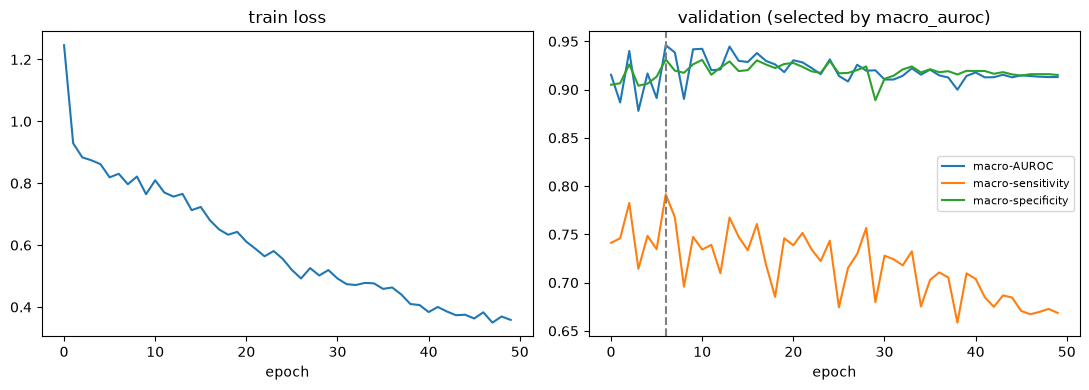

In [8]:
# ---- training curves ----
import matplotlib.pyplot as plt
h = history; ep = [x["epoch"] for x in h]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [x["train_loss"] for x in h]); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
for k, lab in [("val_macro_auroc","macro-AUROC"),
               ("val_macro_sensitivity","macro-sensitivity"),("val_macro_specificity","macro-specificity")]:
    ax[1].plot(ep, [x[k] for x in h], label=lab)
ax[1].axvline(best_epoch, ls="--", c="grey"); ax[1].legend(fontsize=8)
ax[1].set_title(f"validation (selected by {SELECTION_METRIC})"); ax[1].set_xlabel("epoch")
fig.tight_layout(); plt.show()

## Evaluation on TEST + comparison to the MAE baseline
Full eval below (image/eye/patient + referable-DR). Compare eye-level against the
RETFound-MAE baseline (macro-AUROC 0.888, macro-sens 0.657, referable AUROC 0.965). QWK is
not reported for this experiment.

In [9]:
# ============================ evaluate on TEST (best checkpoint) ============================
best = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(best["model"]); model.to(device)
print(f"Best epoch {best['epoch']} | val_macroAUROC {best['val_macro_auroc']:.4f}")
test_paths = [p for p, _ in ds_te.samples]
y_true, y_prob = E.predict(model, dl_te, device)
rep = E.full_report(test_paths, y_true, y_prob, os.path.join(CONFIG["output_dir"], "eval_test"))
r = rep["eye_level"]; b = r["binary_referable"]
print(f"\nEYE-LEVEL (n={r['n']}): macroAUROC={r['macro_auroc_ovr']:.4f}  "
      f"macro_sens={r['macro_sensitivity']:.4f}  macro_spec={r['macro_specificity']:.4f}  acc={r['accuracy']:.4f}")
print("per-class sens/spec:", {['R0','R1','R2','R3'][k]: (round(v['sensitivity'],3), round(v['specificity'],3))
                               for k, v in r['per_class'].items()})
print(f"referable-DR: AUROC={b['auroc']:.4f} sens={b['sensitivity']:.3f} spec={b['specificity']:.3f} @0.5")

/tmp/ipykernel_840377/2705255637.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(ckpt_path, map_location="cpu")


Best epoch 6 | val_macroAUROC 0.9460


/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):



EYE-LEVEL (n=584): macroAUROC=0.9255  macro_sens=0.6987  macro_spec=0.9211  acc=0.8168
per-class sens/spec: {'R0': (0.925, 0.829), 'R1': (0.696, 0.903), 'R2': (0.629, 0.973), 'R3': (0.545, 0.98)}
referable-DR: AUROC=0.9708 sens=0.754 spec=0.968 @0.5


## Notes
- This isolates the **backbone** effect: same data/split/recipe as the MAE baseline. A single
  test split is noisy (R2/R3 ≈ 35/22 eyes) — prefer k-fold CV before ranking the two backbones.
- DINOv2 uses patch14 @224 (16×16 tokens); the MAE model uses patch16. Both are ViT-Large (~303M).
- Full metrics/plots are in `evaluation/` via a matching eval notebook (see README).